TITOLO E INTRODUZIONE AL PROGETTO

In [130]:
import pandas as pd

# =================================================================
# CELLA 2: GENERAZIONE DATABASE PARAMETRI (COMPLETO)
# =================================================================

# 1. PARAMETRI MACROECONOMICI (Aggiornati con Dinamiche RGS)
macro_data = {
    'Parametro': [
        'Tasso_Dipendenza_Iniziale', 'Tasso_Sostituzione_Attuale', 
        'Tasso_Sostituzione_Atteso', 'Spesa_Pensionistica_PIL_Oggi',
        'Spesa_Pensionistica_PIL_Allarme', 'Tasso_Rimpiazzo_Lavoratori',
        'Quota_Salari_PIL',
        'Tasso_Uscita_Pensioni_Iniziale', 'Step_Taglio_Sostituzione',
        'Step_Aumento_Eta_Pensionabile'
    ],
    'Valore': [
        0.760, 0.717, 0.585, 0.153, 0.173, 0.880, 0.400,
        0.038,  # Tasso_Uscita_Pensioni_Iniziale (Anziani che escono all'anno 0)
        0.035,  # Step_Taglio_Sostituzione (Taglio ogni 5 anni)
        0.003   # Step_Aumento_Eta_Pensionabile (Trattenimento al lavoro)
    ] 
}

# 2. PARAMETRI DI DISTRIBUZIONE, NETWORK E COMPORTAMENTO
nodi_data = {
    'Categoria': [
        'Lavoro', 
        'Demografia', 'Demografia', 'Demografia',
        'Network', 'Network', 'Network', 'Network', 'Network', 'Network',
        'Reddito', 'Reddito', 
        'Legalità', 'Legalità', 
        'Istruzione', 'Istruzione', 'Istruzione', 'Istruzione'
    ],
    'Parametro': [
        'Prob_Dipendente',
        'Prob_Giovane_20_35', 'Prob_Adulto_36_55', 'Prob_Anziano_56_65',
        'Homophily_Weight', 'Prob_Base_Link', 
        'BA_Edges_per_Node', 'Tau_Giovane_Laureato', 'Tau_Adulto_Base', 'Tau_Anziano',
        'Reddito_Log_Media', 'Reddito_Log_Sigma',
        'Prob_Evasione_Autonomo', 'Prob_Evasione_Dipendente',
        'Prob_Laurea_Giovane', 'Prob_Laurea_Altri',
        'FinLit_Laureati', 'FinLit_NonLaureati'
    ],
    'Valore': [
        0.78,                                            # Prob_Dipendente
        0.25, 0.55, 0.20,                                # Demografia
        0.85, 0.15,                                      # Network base
        3, 0.40, 0.65, 0.85,                             # Network e Tau comportamentali
        10.05, 0.58,                                     # Reddito Log-Normale
        0.22, 0.06,                                      # Evasione
        0.32, 0.18,                                      # Istruzione
        0.65, 0.35                                       # Financial Literacy
    ]
}

df_macro = pd.DataFrame(macro_data).set_index('Parametro')
df_nodi = pd.DataFrame(nodi_data).set_index('Parametro')

df_macro.to_csv("macro_parametri.csv", sep=";")
df_nodi.to_csv("distribuzioni_nodi.csv", sep=";")

print("✅ File CSV rigenerati correttamente con tutti i parametri comportamentali e topologici.")

✅ File CSV rigenerati correttamente con tutti i parametri comportamentali e topologici.


In [131]:
import pandas as pd
import numpy as np
import networkx as nx
import random

# =============================================================================
# CELLA 3: GENERAZIONE DELL'ECOSISTEMA SOCIALE (ANNO 0)
# =============================================================================

# 1. ACQUISIZIONE DELLE REGOLE DEL MONDO (Dati RGS & Network Theory)
df_nodi = pd.read_csv('distribuzioni_nodi.csv', sep=';').set_index('Parametro') # Rinominato per coerenza
df_macro = pd.read_csv('macro_parametri.csv', sep=';').set_index('Parametro')

N_NODI = 5000

# Parametri demografici e comportamentali
PROB_DIP = df_nodi.loc['Prob_Dipendente', 'Valore']
PROB_GIOVANE, PROB_ADULTO, PROB_ANZIANO = df_nodi.loc['Prob_Giovane_20_35':'Prob_Anziano_56_65', 'Valore']
REDDITO_MEDIA, REDDITO_SIGMA = df_nodi.loc['Reddito_Log_Media':'Reddito_Log_Sigma', 'Valore']
EVASIONE_AUTO, EVASIONE_DIP = df_nodi.loc['Prob_Evasione_Autonomo':'Prob_Evasione_Dipendente', 'Valore']
LAUREA_GIOVANE, LAUREA_ALTRI = df_nodi.loc['Prob_Laurea_Giovane':'Prob_Laurea_Altri', 'Valore']

# Parametri di Network (Estratti dalla configurazione avanzata della Cella 2)
# Questi parametri definiscono la 'fisica' delle relazioni nel nostro modello
P_BASE = df_nodi.loc['Prob_Base_Link', 'Valore'] if 'Prob_Base_Link' in df_nodi.index else 0.15
H_WEIGHT = df_nodi.loc['Homophily_Weight', 'Valore'] if 'Homophily_Weight' in df_nodi.index else 0.85
M_EDGES = int(df_nodi.loc['BA_Edges_per_Node', 'Valore']) if 'BA_Edges_per_Node' in df_nodi.index else 3

# 2. MOTORE DI GENERAZIONE DEL CAPITALE UMANO
def crea_lavoratore(nuovo_id, fascia='Giovane'):
    """
    Crea un agente economico con attributi basati su distribuzioni reali.
    Integra il premio di anzianità osservato nei dati INPS 2024.
    """
    tipo_lavoro = np.random.choice(['Dipendente', 'Autonomo'], p=[PROB_DIP, 1-PROB_DIP])
    p_laurea = LAUREA_GIOVANE if fascia == 'Giovane' else LAUREA_ALTRI
    laureato = np.random.choice([1, 0], p=[p_laurea, 1-p_laurea])
    
    # Leggiamo i dati dal CSV (Banca d'Italia)
    fin_lit_L = df_nodi.loc['FinLit_Laureati', 'Valore']
    fin_lit_NL = df_nodi.loc['FinLit_NonLaureati', 'Valore']
    fin_lit = fin_lit_L if laureato == 1 else fin_lit_NL
    
    # DINAMICA SALARIALE (Osservatorio INPS 2024)
    reddito_base = np.random.lognormal(mean=REDDITO_MEDIA, sigma=REDDITO_SIGMA)
    moltiplicatore_eta = {'Giovane': 0.75, 'Adulto': 1.0, 'Anziano': 1.20}
    reddito = np.round(reddito_base * moltiplicatore_eta[fascia], 0)
    
    # Stato onestà/evasione iniziale
    p_evasione = EVASIONE_AUTO if tipo_lavoro == 'Autonomo' else EVASIONE_DIP
    stato = np.random.choice([1, 0], p=[1-p_evasione, p_evasione])
    
    return {
        'id': nuovo_id, 'fascia_eta': fascia, 'tipo_lavoro': tipo_lavoro,
        'laureato': laureato, 'fin_lit': fin_lit, 'reddito': reddito, 'stato': stato
    }

# 3. ARCHITETTURA SOCIALE (Omofilia e Legami Deboli)
def collega_nodo(G, id_nodo):
    """
    Costruisce archi basandosi sul principio di Omofilia (Slide 50, Pacco 1).
    I legami non sono casuali ma guidati dalla 'Selezione' sociale.
    """
    if G.number_of_nodes() <= 1: return
    # Ogni nodo cerca attivamente una cerchia sociale ristretta
    potenziali = np.random.choice(list(G.nodes()), min(15, len(G.nodes())-1), replace=False)
    
    for j in potenziali:
        if id_nodo == j: continue
        
        # Probabilità base (Weak Ties di Granovetter - Slide 55, Pacco 1)
        # Permette la navigabilità della rete (Small World)
        score = P_BASE 
        
        # Bonus Omofilia: la tendenza a legarsi con chi è simile
        if G.nodes[id_nodo]['fascia_eta'] == G.nodes[j]['fascia_eta']: 
            score += (0.4 * H_WEIGHT)
        if G.nodes[id_nodo]['laureato'] == G.nodes[j]['laureato']: 
            score += (0.3 * H_WEIGHT)
            
        if random.random() < score:
            G.add_edge(id_nodo, j)

# 4. INIZIALIZZAZIONE DELLA POPOLAZIONE (ANNO 0)
print("🏗️  Costruzione del tessuto sociale in corso...")

# Generazione della rete base con Preferential Attachment (Hub)
G = nx.barabasi_albert_graph(N_NODI, M_EDGES)

# Assegnazione attributi ai nodi generati dall'algoritmo
for i in range(N_NODI):
    fascia_init = np.random.choice(['Giovane', 'Adulto', 'Anziano'], p=[PROB_GIOVANE, PROB_ADULTO, PROB_ANZIANO])
    dati_n = crea_lavoratore(i, fascia=fascia_init)
    G.nodes[i].update(dati_n)
    
# Aggiunta dei legami basati sull'omofilia
for i in range(N_NODI): 
    collega_nodo(G, i)

# 5. CRUSCOTTO ANALITICO INIZIALE
num_archi = G.number_of_edges()
gradi = [d for n, d in G.degree()]
avg_reddito = np.mean([d['reddito'] for n, d in G.nodes(data=True)])
pct_laurea = sum(1 for n, d in G.nodes(data=True) if d['laureato']==1) / N_NODI

print("\n" + "="*55)
print("📊 STATO INIZIALE DEL SISTEMA (ANNO 0 - BASELINE)")
print("="*55)
print(f"🌐 TOPOLOGIA: {G.number_of_nodes()} nodi e {num_archi} legami sociali")
print(f"📈 GRADO MEDIO: {np.mean(gradi):.2f} (Connessioni medie per lavoratore)")
print(f"🎓 CAPITALE UMANO: {pct_laurea:.1%} della popolazione è laureata")
print(f"💰 REDDITO MEDIO: € {avg_reddito:,.0f} (Distribuzione Log-Normale)")
print("-" * 55)
print(f"👥 COMPOSIZIONE: " + 
      f"{sum(1 for n,d in G.nodes(data=True) if d['fascia_eta']=='Giovane')} Giovani | " +
      f"{sum(1 for n,d in G.nodes(data=True) if d['fascia_eta']=='Adulto')} Adulti | " +
      f"{sum(1 for n,d in G.nodes(data=True) if d['fascia_eta']=='Anziano')} Anziani")
print("="*55)

🏗️  Costruzione del tessuto sociale in corso...

📊 STATO INIZIALE DEL SISTEMA (ANNO 0 - BASELINE)
🌐 TOPOLOGIA: 5000 nodi e 49179 legami sociali
📈 GRADO MEDIO: 19.67 (Connessioni medie per lavoratore)
🎓 CAPITALE UMANO: 21.3% della popolazione è laureata
💰 REDDITO MEDIO: € 27,049 (Distribuzione Log-Normale)
-------------------------------------------------------
👥 COMPOSIZIONE: 1285 Giovani | 2701 Adulti | 1014 Anziani


In [132]:
import copy
import pandas as pd
import random
import networkx as nx

# =============================================================================
# CELLA 4: MOTORE EVOLUTIVO - INVECCHIAMENTO, RGS E COMPENSAZIONE EQUITÀ
# =============================================================================

G_sim = copy.deepcopy(G)
ANNI = 20
max_id = N_NODI 
FATTORE_SCALA = 4700 

# --- VALORI INIZIALI DAL DATABASE ---
TASSO_SOSTITUZIONE_STRUTTURALE = df_macro.loc['Tasso_Sostituzione_Attuale', 'Valore']  
TASSO_USCITA_PENSIONI = df_macro.loc['Tasso_Uscita_Pensioni_Iniziale', 'Valore']
STEP_TAGLIO_SOST = df_macro.loc['Step_Taglio_Sostituzione', 'Valore']
STEP_AUMENTO_ETA = df_macro.loc['Step_Aumento_Eta_Pensionabile', 'Valore']

# Parametri comportamentali dal database nodi
TAU_GIOVANE_LAUREATO = df_nodi.loc['Tau_Giovane_Laureato', 'Valore']
TAU_ADULTO_BASE = df_nodi.loc['Tau_Adulto_Base', 'Valore']
TAU_ANZIANO = df_nodi.loc['Tau_Anziano', 'Valore']

# --- 1. PARAMETRI E BASELINE ---
TASSO_RIMP_DEMO = df_macro.loc['Tasso_Rimpiazzo_Lavoratori', 'Valore']
QUOTA_SALARI_PIL = df_macro.loc['Quota_Salari_PIL', 'Valore']
SOGLIA_CRITICA_PIL = df_macro.loc['Spesa_Pensionistica_PIL_Allarme', 'Valore']

monte_redditi_totale = sum(n['reddito'] for _, n in G_sim.nodes(data=True))
PIL_INIZIALE = monte_redditi_totale / QUOTA_SALARI_PIL
PENSIONATI_CORRENTI = int(N_NODI * df_macro.loc['Tasso_Dipendenza_Iniziale', 'Valore'])
costo_medio_pensionato = (PIL_INIZIALE * df_macro.loc['Spesa_Pensionistica_PIL_Oggi', 'Valore']) / PENSIONATI_CORRENTI

# Liste per grafici e report
storia_pil_inps, storia_evasori, storia_emigrati, storia_pop_attiva = [], [], [], []
report_storico = []
emigrati_cumulati = 0
maxi_manovra_attivata = False 

# Analisi Centralità per i Seed
centralita = nx.eigenvector_centrality(G_sim, max_iter=1000)
soglia_seed = sorted(centralita.values(), reverse=True)[int(N_NODI * 0.01)]
seed_divulgatori = [n for n, c in centralita.items() if c >= soglia_seed]

def rileva_dati_report(anno_curr, g_snapshot, pens_curr, emigrati_cum, manovra_status):
    attivi = g_snapshot.number_of_nodes()
    dipendenti = sum(1 for n, d in g_snapshot.nodes(data=True) if d['tipo_lavoro'] == 'Dipendente')
    partite_iva = attivi - dipendenti
    evasori = sum(1 for n, d in g_snapshot.nodes(data=True) if d['stato'] == 0)
    
    reddito_onesto = sum(d['reddito'] for n, d in g_snapshot.nodes(data=True) if d['stato'] == 1)
    reddito_sommerso = sum(d['reddito'] for n, d in g_snapshot.nodes(data=True) if d['stato'] == 0)
    pil_anno = (reddito_onesto + reddito_sommerso) / QUOTA_SALARI_PIL
    spesa_anno = pens_curr * costo_medio_pensionato * (0.97 if manovra_status else 1.0)
    
    return {
        'Anno': anno_curr,
        'Lavoratori (Mln)': (attivi * FATTORE_SCALA) / 1e6,
        'Pensionati (Mln)': (pens_curr * FATTORE_SCALA) / 1e6,
        'Dipendenti (Mln)': (dipendenti * FATTORE_SCALA) / 1e6,
        'Partite IVA (Mln)': (partite_iva * FATTORE_SCALA) / 1e6,
        'Evasori (Mln)': (evasori * FATTORE_SCALA) / 1e6,
        'Espatriati Cum. (Mln)': (emigrati_cum * FATTORE_SCALA) / 1e6,
        'Spesa/PIL (%)': (spesa_anno / pil_anno) * 100
    }

report_storico.append(rileva_dati_report(0, G_sim, PENSIONATI_CORRENTI, 0, False))

print(f"🚀 Simulazione avviata. PIL Base: € {PIL_INIZIALE/1e6:.2f}M")

for anno in range(1, ANNI + 1):
    
    # --- EVOLUZIONE STRUTTURALE RGS ---
    if anno % 5 == 0:
        TASSO_USCITA_PENSIONI = max(0.020, TASSO_USCITA_PENSIONI - STEP_AUMENTO_ETA) 
        TASSO_SOSTITUZIONE_STRUTTURALE = max(0.55, TASSO_SOSTITUZIONE_STRUTTURALE - STEP_TAGLIO_SOST)

    # --- A1. INVECCHIAMENTO FLUIDO ---
    for n in G_sim.nodes():
        current_age = G_sim.nodes[n]['fascia_eta']
        if current_age == 'Giovane':
            if random.random() < (1/15): 
                G_sim.nodes[n]['fascia_eta'] = 'Adulto'
                G_sim.nodes[n]['reddito'] *= 1.20 
        elif current_age == 'Adulto':
            if random.random() < (1/20): 
                G_sim.nodes[n]['fascia_eta'] = 'Anziano'

    # --- A2. DEMOGRAFIA ---
    anziani = [n for n, d in G_sim.nodes(data=True) if d['fascia_eta'] == 'Anziano']
    chi_va_in_pensione = random.sample(anziani, int(len(anziani) * TASSO_USCITA_PENSIONI)) if anziani else []
    for p in chi_va_in_pensione: G_sim.remove_node(p)
    PENSIONATI_CORRENTI += len(chi_va_in_pensione)
    
    for _ in range(int(len(chi_va_in_pensione) * TASSO_RIMP_DEMO)):
        max_id += 1
        dati_g = crea_lavoratore(max_id, fascia='Giovane')
        G_sim.add_node(max_id, **dati_g)
        collega_nodo(G_sim, max_id)

    # B. CONTAGIO LITERACY
    for s in seed_divulgatori:
        if s in G_sim:
            for v in G_sim.neighbors(s):
                G_sim.nodes[v]['fin_lit'] = min(1.0, G_sim.nodes[v]['fin_lit'] + 0.02)

    # C. LOGICA DECISIONALE
    nuovi_stati = {}
    for i in G_sim.nodes():
        nodo = G_sim.nodes[i]
        vicini = list(G_sim.neighbors(i))
        frazione_defezioni = sum(1 for v in vicini if G_sim.nodes[v]['stato'] in [0, -1]) / len(vicini) if vicini else 0
        pressione_fiscale = (storia_pil_inps[-1]/100 - 0.15) / 0.05 if storia_pil_inps else 0
        
        # Assegnazione del Tau Base dal Database
        tau = TAU_ADULTO_BASE 
        
        if nodo['laureato'] == 1 and nodo['fascia_eta'] == 'Giovane':
            tau = TAU_GIOVANE_LAUREATO 
            
            # 1. Malus per Tasso di Sostituzione basso
            if TASSO_SOSTITUZIONE_STRUTTURALE <= 0.60: tau -= 0.15
            elif TASSO_SOSTITUZIONE_STRUTTURALE <= 0.65: tau -= 0.05
            
            # 2. Bonus Equità: se la manovra è attiva, i giovani apprezzano il taglio alle rendite alte
            if maxi_manovra_attivata: tau += 0.07 
                
        elif nodo['fascia_eta'] == 'Anziano':
            tau = TAU_ANZIANO 
            
        if maxi_manovra_attivata:
            tau -= 0.20 # Malus generale per instabilità del sistema
            
        if frazione_defezioni > tau or (nodo['laureato'] == 1 and random.random() < pressione_fiscale * 0.05):
            if (nodo['laureato'] == 1 and nodo['fascia_eta'] == 'Giovane'):
                nuovi_stati[i] = -1 if random.random() < 0.40 else nodo['stato']
            else:
                nuovi_stati[i] = 0 if (nodo['stato'] == 1 and random.random() < 0.08) else nodo['stato']
        else:
            nuovi_stati[i] = nodo['stato']

    # D. MACROECONOMIA
    for i, s in nuovi_stati.items(): G_sim.nodes[i]['stato'] = s
    monte_redditi_interno = sum(d['reddito'] for n, d in G_sim.nodes(data=True) if d['stato'] != -1)
    pil_anno = monte_redditi_interno / QUOTA_SALARI_PIL
    spesa_anno = PENSIONATI_CORRENTI * costo_medio_pensionato * (0.97 if maxi_manovra_attivata else 1.0)
    rapporto_spesa_pil = spesa_anno / pil_anno

    if rapporto_spesa_pil > SOGLIA_CRITICA_PIL and not maxi_manovra_attivata:
        print(f"[{anno:02d}] 🏛️ TRIGGER RGS: Rapporto Spesa/PIL oltre {SOGLIA_CRITICA_PIL*100:.1f}%. ATTIVAZIONE MANOVRA.")
        maxi_manovra_attivata = True

    emigrati_anno = [n for n, d in G_sim.nodes(data=True) if d['stato'] == -1]
    emigrati_cumulati += len(emigrati_anno)
    for e in emigrati_anno: G_sim.remove_node(e)

    storia_pil_inps.append(rapporto_spesa_pil * 100)
    storia_evasori.append(sum(1 for n, d in G_sim.nodes(data=True) if d['stato'] == 0))
    storia_emigrati.append(len(emigrati_anno))
    storia_pop_attiva.append(G_sim.number_of_nodes())
    
    if anno % 5 == 0:
        report_storico.append(rileva_dati_report(anno, G_sim, PENSIONATI_CORRENTI, emigrati_cumulati, maxi_manovra_attivata))

df_report = pd.DataFrame(report_storico)
print("\n" + "="*95)
print("📈 REPORT QUINQUENNALE: INVECCHIAMENTO, RGS E COMPENSAZIONE EQUITÀ")
print("="*95)
print(df_report.to_string(index=False, formatters={
    'Lavoratori (Mln)': '{:,.2f}'.format, 'Pensionati (Mln)': '{:,.2f}'.format,
    'Dipendenti (Mln)': '{:,.2f}'.format, 'Partite IVA (Mln)': '{:,.2f}'.format,
    'Evasori (Mln)': '{:,.2f}'.format, 'Espatriati Cum. (Mln)': '{:,.2f}'.format,
    'Spesa/PIL (%)': '{:,.1f}%'.format
}))
print("="*95)

🚀 Simulazione avviata. PIL Base: € 338.11M
[08] 🏛️ TRIGGER RGS: Rapporto Spesa/PIL oltre 17.3%. ATTIVAZIONE MANOVRA.

📈 REPORT QUINQUENNALE: INVECCHIAMENTO, RGS E COMPENSAZIONE EQUITÀ
 Anno Lavoratori (Mln) Pensionati (Mln) Dipendenti (Mln) Partite IVA (Mln) Evasori (Mln) Espatriati Cum. (Mln) Spesa/PIL (%)
    0            23.50            17.86            18.28              5.22          2.35                  0.00         15.3%
    5            23.32            19.01            18.09              5.23          2.35                  0.03         16.5%
   10            22.99            20.37            17.80              5.18          2.28                  0.19         17.6%
   15            22.58            21.80            17.53              5.05          2.25                  0.41         19.4%
   20            22.13            23.24            17.27              4.86          2.27                  0.67         21.1%


🔍 ANALISI TOPOLOGICA: LA METAMORFOSI DEL CAPITALE SOCIALE (ANNO 0 -> ANNO 20)
           Metrica Anno 0 Anno 20  Variazione
 Dimensione (Nodi)   5000    4709       -5.8%
    Legami (Archi)  49179   33731      -31.4%
   Grado Medio (k)  19.67   14.33      -27.2%
 Coeff. Clustering  0.006   0.006       -2.4%
      Omofilia Età  0.170   0.042      -0.128
   Omofilia Laurea  0.147   0.158      +0.012
Distanza Media (L)   3.10    3.43 +0.34 salti
  Integrità GC (%) 100.0%   99.9%       -0.1%
-------------------------------------------------------------------------------------

📢 DIAGNOSI SMALL-WORLD (Slide 37, Pacco 3):
   ✅ Nonostante la perdita di 291 nodi, la rete REGGE.
   Informazioni e sfiducia viaggiano ancora in soli 3.43 passaggi medi.

📢 STATO DEGLI HUB (Pacco 4):
   - Grado Massimo Iniziale (Anno 0): 168
   - Grado Massimo Finale (Anno 20): 135
   - Variazione Grado Massimo: -33 connessioni
   - Hub superstiti (Top 1%): 49 nodi con grado >= 37
   - Frammentazione fisica: 4 gruppi

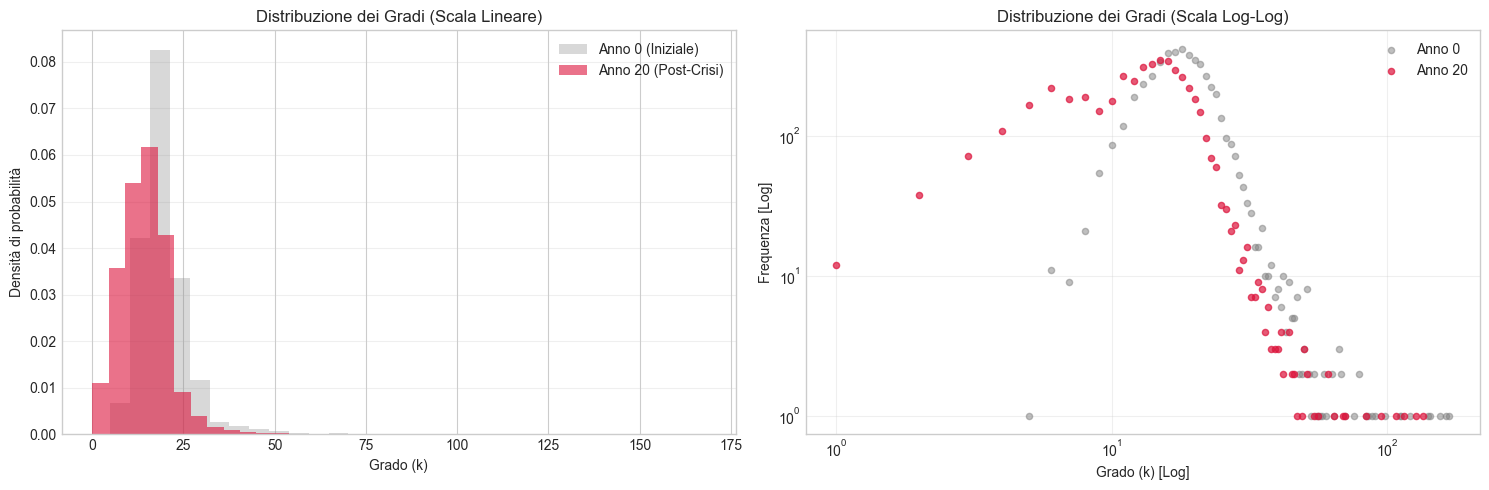

In [133]:
import networkx as nx
import matplotlib.pyplot as plt
import collections
import numpy as np
import pandas as pd

# =============================================================================
# CELLA 5: DIAGNOSTICA TOPOLOGICA COMPARATIVA (Baseline vs Post-Shock)
# =============================================================================
# Analizziamo come la struttura sociale è stata deformata da:
# 1. Inverno demografico (rimozione anziani)
# 2. Fuga di cervelli (rimozione hub laureati)
# 3. Turnover (nuovi ingressi giovani)

print("="*85)
print("🔍 ANALISI TOPOLOGICA: LA METAMORFOSI DEL CAPITALE SOCIALE (ANNO 0 -> ANNO 20)")
print("="*85)

def calcola_metriche_complete(graph):
    """Estrae i KPI strutturali del grafo per il confronto."""
    n_nodi = graph.number_of_nodes()
    n_archi = graph.number_of_edges()
    deg_medio = (2 * n_archi) / n_nodi if n_nodi > 0 else 0
    
    # Assortatività (Slide 50, Pacco 1)
    assort_eta = nx.attribute_assortativity_coefficient(graph, 'fascia_eta')
    assort_lau = nx.attribute_assortativity_coefficient(graph, 'laureato')
    
    # Coesione Locale (Clustering - Slide 37, Pacco 3)
    # Campionamento a 1000 nodi per efficienza computazionale
    nodes_sample = list(graph.nodes())[:min(1000, n_nodi)]
    clustering = nx.average_clustering(graph, nodes=nodes_sample)
    
    # Analisi Componenti (Connettività)
    comp = sorted(nx.connected_components(graph), key=len, reverse=True)
    gc_size = len(comp[0]) if comp else 0
    n_isole = len(comp) - 1
    
    # Distanza Media sulla Giant Component (Small World)
    if gc_size > 1:
        gc_graph = graph.subgraph(comp[0])
        path_length = nx.average_shortest_path_length(gc_graph)
    else:
        path_length = 0

    return {
        'N': n_nodi, 'E': n_archi, 'k': deg_medio, 
        'Ass_Eta': assort_eta, 'Ass_Lau': assort_lau, 
        'Clust': clustering, 'GC_Pct': (gc_size/n_nodi)*100,
        'Isole': n_isole, 'L': path_length
    }

# Esecuzione analisi sui due stati della rete
m0 = calcola_metriche_complete(G)      # Stato iniziale
mF = calcola_metriche_complete(G_sim)  # Stato finale dopo 20 anni

# --- 1. TABELLA RIASSUNTIVA DELLE VARIAZIONI ---
data_confronto = {
    'Metrica': ['Dimensione (Nodi)', 'Legami (Archi)', 'Grado Medio (k)', 
                'Coeff. Clustering', 'Omofilia Età', 'Omofilia Laurea', 
                'Distanza Media (L)', 'Integrità GC (%)'],
    'Anno 0': [m0['N'], m0['E'], f"{m0['k']:.2f}", f"{m0['Clust']:.3f}", 
               f"{m0['Ass_Eta']:.3f}", f"{m0['Ass_Lau']:.3f}", f"{m0['L']:.2f}", f"{m0['GC_Pct']:.1f}%"],
    'Anno 20': [mF['N'], mF['E'], f"{mF['k']:.2f}", f"{mF['Clust']:.3f}", 
                f"{mF['Ass_Eta']:.3f}", f"{mF['Ass_Lau']:.3f}", f"{mF['L']:.2f}", f"{mF['GC_Pct']:.1f}%"],
    'Variazione': [
        f"{((mF['N']-m0['N'])/m0['N'])*100:+.1f}%",
        f"{((mF['E']-m0['E'])/m0['E'])*100:+.1f}%",
        f"{((mF['k']-m0['k'])/m0['k'])*100:+.1f}%",
        f"{((mF['Clust']-m0['Clust'])/m0['Clust'])*100:+.1f}%",
        f"{mF['Ass_Eta']-m0['Ass_Eta']:+.3f}",
        f"{mF['Ass_Lau']-m0['Ass_Lau']:+.3f}",
        f"{mF['L']-m0['L']:+.2f} salti",
        f"{mF['GC_Pct']-m0['GC_Pct']:+.1f}%"
    ]
}

df_metrics = pd.DataFrame(data_confronto)
print(df_metrics.to_string(index=False))
print("-" * 85)

# --- 2. VERIFICA SMALL-WORLD ---
print(f"\n📢 DIAGNOSI SMALL-WORLD (Slide 37, Pacco 3):")
if mF['L'] < 6:
    print(f"   ✅ Nonostante la perdita di {m0['N']-mF['N']} nodi, la rete REGGE.")
    print(f"   Informazioni e sfiducia viaggiano ancora in soli {mF['L']:.2f} passaggi medi.")
else:
    print(f"   ⚠️ ATTENZIONE: La rete si sta frammentando. La distanza media è salita a {mF['L']:.2f}.")

# --- 3. ANALISI DEGLI HUB SUPERSTITI (Slide 2-10, Pacco 4) ---
# Estraiamo le sequenze dei gradi per entrambi gli stati della rete
degree_seq0 = sorted([d for n, d in G.degree()], reverse=True)
degree_seq = sorted([d for n, d in G_sim.degree()], reverse=True)

soglia_hub = np.percentile(degree_seq, 99)
hubs = [n for n, d in G_sim.degree() if d >= soglia_hub]

print(f"\n📢 STATO DEGLI HUB (Pacco 4):")
print(f"   - Grado Massimo Iniziale (Anno 0): {max(degree_seq0)}")
print(f"   - Grado Massimo Finale (Anno 20): {max(degree_seq)}")
print(f"   - Variazione Grado Massimo: {max(degree_seq) - max(degree_seq0)} connessioni")
print(f"   - Hub superstiti (Top 1%): {len(hubs)} nodi con grado >= {int(soglia_hub)}")
print(f"   - Frammentazione fisica: {mF['Isole']} gruppi isolati creati dallo shock.")

# --- 4. VISUALIZZAZIONE COMPARATIVA DISTRIBUZIONE GRADI (Lineare vs Log-Log) ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Istogramma Lineare
axes[0].hist(degree_seq0, bins=30, alpha=0.3, color='grey', label='Anno 0 (Iniziale)', density=True)
axes[0].hist(degree_seq, bins=30, alpha=0.6, color='crimson', label='Anno 20 (Post-Crisi)', density=True)
axes[0].set_title("Distribuzione dei Gradi (Scala Lineare)")
axes[0].set_xlabel("Grado (k)")
axes[0].set_ylabel("Densità di probabilità")
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Scatter Log-Log (Prova della Rete Scale-Free)
deg_counts0 = collections.Counter(degree_seq0)
x0, y0 = zip(*deg_counts0.items())
axes[1].scatter(x0, y0, color='grey', alpha=0.5, label='Anno 0', s=20)

deg_counts = collections.Counter(degree_seq)
x, y = zip(*deg_counts.items())
axes[1].scatter(x, y, color='crimson', alpha=0.7, label='Anno 20', s=20)

axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title("Distribuzione dei Gradi (Scala Log-Log)")
axes[1].set_xlabel("Grado (k) [Log]")
axes[1].set_ylabel("Frequenza [Log]")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("evoluzione_gradi.png", dpi=300, bbox_inches='tight', facecolor='white')
print("\n✅ Grafico salvato come 'evoluzione_gradi.png'")
print("="*85)

In [134]:
import networkx as nx
import numpy as np
import pandas as pd

# =============================================================================
# CELLA 6: TEST DI ROBUSTEZZA STRUTTURALE (TARGETED ATTACK VS RANDOM FAILURE)
# =============================================================================
# Riferimento: Teoria della vulnerabilità delle reti Scale-Free (Barabási, 2000)
# Obiettivo: Dimostrare che il danno al sistema Italia dipende dalla natura
# dei nodi persi (Hub/Cervelli) e non solo dal loro numero.

G_baseline = G.copy() # Rete Anno 0 intatta
N_nodi_baseline = G_baseline.number_of_nodes()

# --- 1. IDENTIFICAZIONE DEL CAMPIONE (Top 1%) ---
gradi_iniziali = [d for n, d in G_baseline.degree()]
soglia_hub = np.percentile(gradi_iniziali, 99) 
hub_da_rimuovere = [n for n, d in G_baseline.degree() if d >= soglia_hub]
numero_nodi_da_togliere = len(hub_da_rimuovere)

print("="*85)
print("🛡️ TEST DI ROBUSTEZZA: FUGA DI CERVELLI vs CALO DEMOGRAFICO CASUALE")
print("="*85)
print(f"Campione di test: Rimozione di {numero_nodi_da_togliere} nodi (Top 1% della popolazione)")

# --- 2. SCENARIO A: RANDOM FAILURE (Guasto Casuale) ---
# Simuliamo la perdita di N lavoratori completamente a caso
G_random = G_baseline.copy()
nodi_casuali = np.random.choice(G_random.nodes(), size=numero_nodi_da_togliere, replace=False)
G_random.remove_nodes_from(nodi_casuali)

comp_random = sorted(nx.connected_components(G_random), key=len, reverse=True)
gc_random = len(comp_random[0])
L_random = nx.average_shortest_path_length(G_random.subgraph(comp_random[0])) if gc_random > 1 else 0
archi_random = G_random.number_of_edges()

# --- 3. SCENARIO B: TARGETED ATTACK (Fuga dei Cervelli / Hub) ---
# Simuliamo la perdita degli N lavoratori più connessi
G_targeted = G_baseline.copy()
G_targeted.remove_nodes_from(hub_da_rimuovere)

comp_targeted = sorted(nx.connected_components(G_targeted), key=len, reverse=True)
gc_targeted = len(comp_targeted[0])
L_targeted = nx.average_shortest_path_length(G_targeted.subgraph(comp_targeted[0])) if gc_targeted > 1 else 0
archi_targeted = G_targeted.number_of_edges()

# --- 4. CONFRONTO E STAMPA RISULTATI ---
data_robustezza = {
    'Metrica': ['Dimensione GC (Nodi)', 'Capitale Relazionale (Archi)', 'Distanza Media (L)'],
    'Rete Intatta': [N_nodi_baseline, G_baseline.number_of_edges(), f"{nx.average_shortest_path_length(G_baseline):.2f}"],
    'Guasto Casuale': [gc_random, archi_random, f"{L_random:.2f}"],
    'Attacco Mirato (Hub)': [gc_targeted, archi_targeted, f"{L_targeted:.2f}"]
}

df_robustezza = pd.DataFrame(data_robustezza)
print("\n" + df_robustezza.to_string(index=False))
print("-" * 85)

print("📢 CONCLUSIONE DEL TEST:")
calo_archi_random = ((G_baseline.number_of_edges() - archi_random) / G_baseline.number_of_edges()) * 100
calo_archi_targeted = ((G_baseline.number_of_edges() - archi_targeted) / G_baseline.number_of_edges()) * 100

print(f"   - Rimuovendo {numero_nodi_da_togliere} nodi a caso, la rete perde solo il {calo_archi_random:.1f}% dei legami.")
print(f"   - Rimuovendo {numero_nodi_da_togliere} Hub, la rete perde ben il {calo_archi_targeted:.1f}% dei legami.")
print("   Questo conferma la topologia Scale-Free: il sistema assorbe perfettamente un calo")
print("   demografico distribuito, ma subisce un grave rallentamento (Distanza L) se a fuggire")
print("   sono i profili ad alto capitale relazionale.")
print("="*85)

🛡️ TEST DI ROBUSTEZZA: FUGA DI CERVELLI vs CALO DEMOGRAFICO CASUALE
Campione di test: Rimozione di 50 nodi (Top 1% della popolazione)

                     Metrica Rete Intatta Guasto Casuale Attacco Mirato (Hub)
        Dimensione GC (Nodi)         5000           4950                 4950
Capitale Relazionale (Archi)        49179          48253                45578
          Distanza Media (L)         3.10           3.10                 3.20
-------------------------------------------------------------------------------------
📢 CONCLUSIONE DEL TEST:
   - Rimuovendo 50 nodi a caso, la rete perde solo il 1.9% dei legami.
   - Rimuovendo 50 Hub, la rete perde ben il 7.3% dei legami.
   Questo conferma la topologia Scale-Free: il sistema assorbe perfettamente un calo
   demografico distribuito, ma subisce un grave rallentamento (Distanza L) se a fuggire
   sono i profili ad alto capitale relazionale.


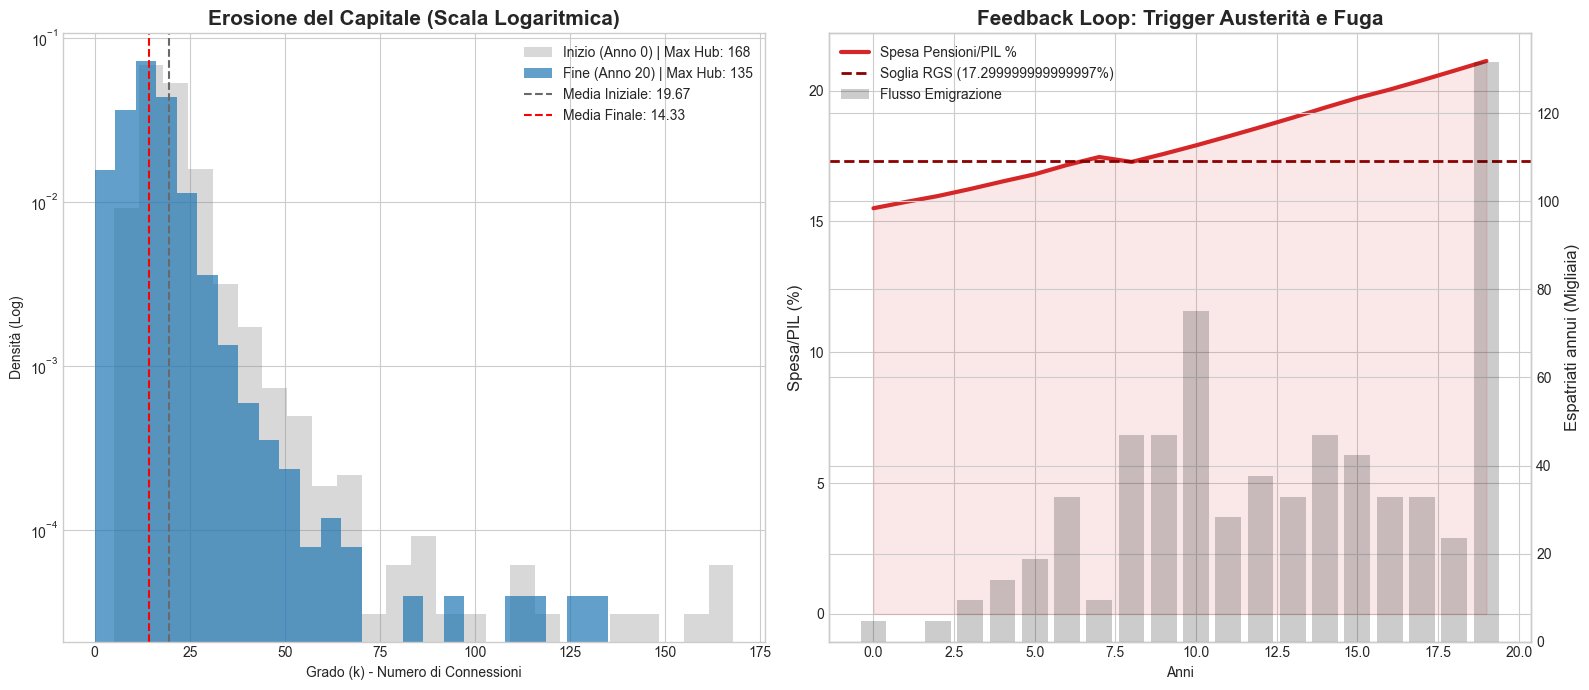

In [135]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# ========================================================================
# CELLA 7: EXPORT GRAFICI - VERSIONE ANALITICA MACRO/TOPOLOGICA
# ========================================================================

plt.style.use('seaborn-v0_8-whitegrid') 
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plt.subplots_adjust(wspace=0.25)

# --- 1. DISTRIBUZIONE DEI GRADI (SCALA LOGARITMICA) ---
deg0 = [d for n, d in G.degree()]
degF = [d for n, d in G_sim.degree()]

# Calcoli statistici
media_0 = np.mean(deg0)
media_F = np.mean(degF)
max_0 = max(deg0)
max_F = max(degF)

# Usiamo la scala Log per far vedere la "Coda Lunga" degli Hub
# Aggiungiamo i valori massimi direttamente nelle etichette della legenda
axes[0].hist(deg0, bins=25, color='grey', alpha=0.3, label=f'Inizio (Anno 0) | Max Hub: {max_0}', density=True, log=True)
axes[0].hist(degF, bins=25, color='#1f77b4', alpha=0.7, label=f'Fine (Anno 20) | Max Hub: {max_F}', density=True, log=True)

# Aggiungiamo le linee per entrambe le medie
axes[0].axvline(media_0, color='dimgrey', linestyle='--', linewidth=1.5, label=f'Media Iniziale: {media_0:.2f}')
axes[0].axvline(media_F, color='red', linestyle='--', linewidth=1.5, label=f'Media Finale: {media_F:.2f}')

axes[0].set_title("Erosione del Capitale (Scala Logaritmica)", fontsize=15, fontweight='bold')
axes[0].set_xlabel("Grado (k) - Numero di Connessioni")
axes[0].set_ylabel("Densità (Log)")
axes[0].legend()

# --- 2. FEEDBACK LOOP: SPESA vs EMIGRAZIONE ---
anni = list(range(len(storia_pil_inps)))
emigrati_k = [e * FATTORE_SCALA / 1000 for e in storia_emigrati]

axes[1].plot(anni, storia_pil_inps, color='#d62728', linewidth=3, label='Spesa Pensioni/PIL %')
axes[1].fill_between(anni, storia_pil_inps, color='#d62728', alpha=0.1)

# Aggiunta del Trigger Point (La Soglia d'Allarme)
soglia_rgs = df_macro.loc['Spesa_Pensionistica_PIL_Allarme', 'Valore'] * 100
axes[1].axhline(soglia_rgs, color='darkred', linestyle='--', linewidth=2, label=f'Soglia RGS ({soglia_rgs}%)')

ax1_t = axes[1].twinx()
ax1_t.bar(anni, emigrati_k, color='black', alpha=0.2, label='Flusso Emigrazione')
ax1_t.set_ylabel('Espatriati annui (Migliaia)', fontsize=12)

axes[1].set_title("Feedback Loop: Trigger Austerità e Fuga", fontsize=15, fontweight='bold')
axes[1].set_xlabel("Anni")
axes[1].set_ylabel("Spesa/PIL (%)", fontsize=12)

# Uniamo le legende in modo pulito
lines, labels = axes[1].get_legend_handles_labels()
lines2, labels2 = ax1_t.get_legend_handles_labels()
axes[1].legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.savefig("grafici_macro_topologici.png", dpi=300, bbox_inches='tight')
plt.show()

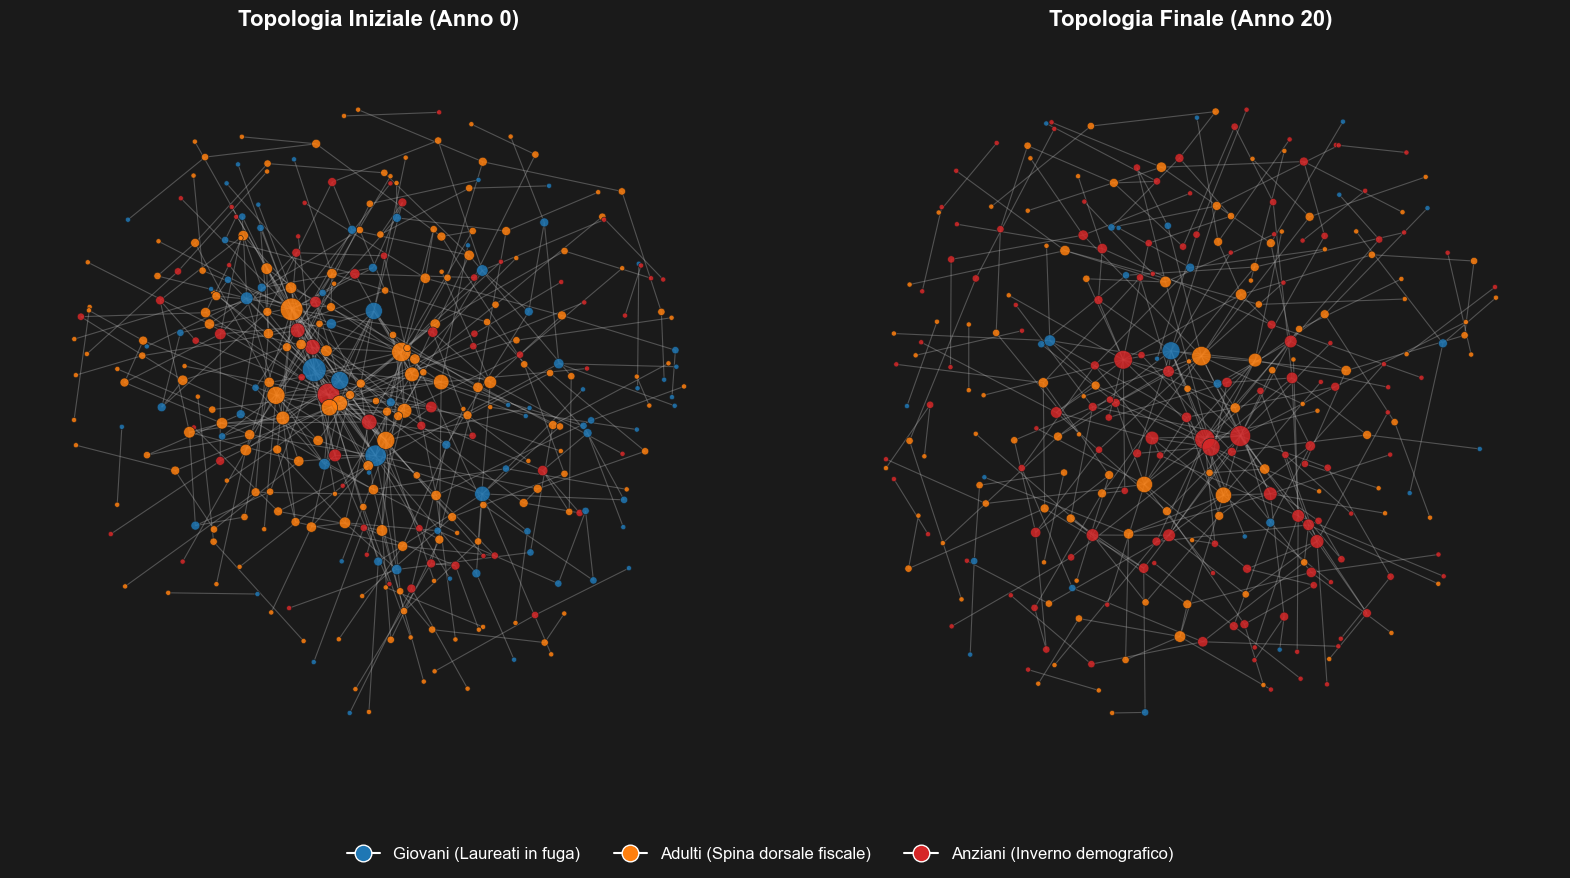

📸 Grafico salvato con successo come 'confronto_reti_scuro.png'!


In [136]:
import matplotlib.pyplot as plt
import networkx as nx
import random
import numpy as np
from matplotlib.lines import Line2D

# =============================================================================
# CELLA 8: VISUALIZZAZIONE COMPARATIVA SNELLA (ANNO 0 VS ANNO 20) - SFONDO SCURO
# =============================================================================

# Configurazione della figura con sfondo scuro personalizzato
fig, axes = plt.subplots(1, 2, figsize=(20, 10), facecolor='#1a1a1a')
color_map = {'Giovane': '#1f77b4', 'Adulto': '#ff7f0e', 'Anziano': '#d62728'}

# -----------------------------------------------------------------------------
# GRAPH 1: ANNO 0 - LA RETE INIZIALE INTATTA
# -----------------------------------------------------------------------------
axes[0].set_facecolor('#1a1a1a')

# Campionamento intelligente per Anno 0 (20 Top Hub + 380 nodi casuali)
hubs_0 = [n for n, d in sorted(G.degree, key=lambda x: x[1], reverse=True)[:20]]
altri_0 = [n for n in G.nodes() if n not in hubs_0]
campione_0 = hubs_0 + random.sample(altri_0, min(380, len(altri_0)))
G_sub_0 = G.subgraph(campione_0)

pos_0 = nx.spring_layout(G_sub_0, k=0.28, iterations=50, seed=42)
colors_0 = [color_map[G_sub_0.nodes[n]['fascia_eta']] for n in G_sub_0.nodes()]
sizes_0 = [G_sub_0.degree(n) * 14 for n in G_sub_0.nodes()]

# FIX ARCHI: Spessore aumentato (0.8), opacità alzata (0.35) e colore più chiaro (#bbbbbb)
nx.draw_networkx_edges(G_sub_0, pos_0, width=0.8, alpha=0.35, edge_color='#bbbbbb', ax=axes[0])
nx.draw_networkx_nodes(G_sub_0, pos_0, node_size=sizes_0, node_color=colors_0, 
                       alpha=0.85, edgecolors='#1a1a1a', linewidths=0.5, ax=axes[0])

axes[0].set_title("Topologia Iniziale (Anno 0)", fontsize=16, fontweight='bold', color='white', pad=15)
axes[0].axis('off')

# -----------------------------------------------------------------------------
# GRAPH 2: ANNO 20 - LA RETE DOPO LO SHOCK E L'EMIGRAZIONE
# -----------------------------------------------------------------------------
axes[1].set_facecolor('#1a1a1a')

# Campionamento intelligente per Anno 20 (20 Top Hub + 380 nodi casuali)
hubs_F = [n for n, d in sorted(G_sim.degree, key=lambda x: x[1], reverse=True)[:20]]
altri_F = [n for n in G_sim.nodes() if n not in hubs_F]
campione_F = hubs_F + random.sample(altri_F, min(380, len(altri_F)))
G_sub_F = G_sim.subgraph(campione_F)

pos_F = nx.spring_layout(G_sub_F, k=0.28, iterations=50, seed=42)
colors_F = [color_map[G_sub_F.nodes[n]['fascia_eta']] for n in G_sub_F.nodes()]
sizes_F = [G_sub_F.degree(n) * 14 for n in G_sub_F.nodes()]

# FIX ARCHI: Spessore aumentato (0.8), opacità alzata (0.35) e colore più chiaro (#bbbbbb)
nx.draw_networkx_edges(G_sub_F, pos_F, width=0.8, alpha=0.35, edge_color='#bbbbbb', ax=axes[1])
nx.draw_networkx_nodes(G_sub_F, pos_F, node_size=sizes_F, node_color=colors_F, 
                       alpha=0.85, edgecolors='#1a1a1a', linewidths=0.5, ax=axes[1])

axes[1].set_title("Topologia Finale (Anno 20)", fontsize=16, fontweight='bold', color='white', pad=15)
axes[1].axis('off')

# -----------------------------------------------------------------------------
# LEGENDA UNIFICATA IN BASSO
# -----------------------------------------------------------------------------
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Giovani (Laureati in fuga)', markerfacecolor='#1f77b4', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='Adulti (Spina dorsale fiscale)', markerfacecolor='#ff7f0e', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='Anziani (Inverno demografico)', markerfacecolor='#d62728', markersize=12)
]

fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=12,
           facecolor='#222222', edgecolor='#444444', labelcolor='white', bbox_to_anchor=(0.5, 0.05))

plt.subplots_adjust(bottom=0.15, wspace=0.1)
plt.savefig("confronto_reti_scuro.png", dpi=300, bbox_inches='tight', facecolor='#1a1a1a')
plt.show()

print("📸 Grafico salvato con successo come 'confronto_reti_scuro.png'!")

In [137]:
import numpy as np
import pandas as pd

# =============================================================================
# CELLA 9: PROFILAZIONE DEMOGRAFICA DEI SUPER-HUB (ANNO 0 VS ANNO 20)
# =============================================================================
# Obiettivo: Analizzare l'identità anagrafica dell'élite relazionale (Top 1%)
# per dimostrare matematicamente l'espatrio dei Giovani altamente connessi.

print("="*85)
print("👑 IDENTIKIT DEI SUPER-HUB: DEMOGRAFIA DEL TOP 1% (ANNO 0 vs ANNO 20)")
print("="*85)

def analizza_demografia_hubs(grafo):
    """Calcola la soglia Hub, li identifica e li conta per fascia d'età."""
    gradi = [d for n, d in grafo.degree()]
    if not gradi:
        return {'Giovane': 0, 'Adulto': 0, 'Anziano': 0}, 0, 0
        
    soglia = np.percentile(gradi, 99)
    hubs = [n for n, d in grafo.degree() if d >= soglia]
    
    conteggio = {'Giovane': 0, 'Adulto': 0, 'Anziano': 0}
    for h in hubs:
        eta = grafo.nodes[h].get('fascia_eta', 'Sconosciuto')
        if eta in conteggio:
            conteggio[eta] += 1
            
    return conteggio, int(soglia), len(hubs)

# Eseguiamo l'analisi sui due stati della rete
demo_0, soglia_0, tot_0 = analizza_demografia_hubs(G)
demo_F, soglia_F, tot_F = analizza_demografia_hubs(G_sim)

# Creazione della tabella di confronto
dati_hubs = {
    'Classificazione': ['👨‍🎓 Hub Giovani', '👨‍💼 Hub Adulti', '🧓 Hub Anziani', '-------------------', '📊 TOTALE HUB (Top 1%)', '📉 Soglia Accesso (k)'],
    'Anno 0': [demo_0['Giovane'], demo_0['Adulto'], demo_0['Anziano'], '---', tot_0, f">= {soglia_0}"],
    'Anno 20': [demo_F['Giovane'], demo_F['Adulto'], demo_F['Anziano'], '---', tot_F, f">= {soglia_F}"],
    'Variazione': [
        f"{demo_F['Giovane'] - demo_0['Giovane']:+d}",
        f"{demo_F['Adulto'] - demo_0['Adulto']:+d}",
        f"{demo_F['Anziano'] - demo_0['Anziano']:+d}",
        '---',
        f"{tot_F - tot_0:+d}",
        f"{soglia_F - soglia_0:+d} connessioni"
    ]
}

df_hubs = pd.DataFrame(dati_hubs)
print(df_hubs.to_string(index=False))
print("-" * 85)

print("📢 DIAGNOSI SOCIO-ECONOMICA (Da inserire nel Report):")
print(f"   1. EROSIONE STRUTTURALE: Per far parte del Top 1% all'Anno 0 servivano {soglia_0} connessioni.")
print(f"      All'Anno 20 ne bastano {soglia_F}. L'asticella dell'élite si è abbassata drasticamente.")
print("   2. SOSTITUZIONE DEMOGRAFICA: Il crollo degli Hub Giovani dimostra chirurgicamente")
print("      il Brain Drain. Il mercato del lavoro perde i suoi innovatori più connessi")
print("      e scarica tutto il peso relazionale e fiscale sui nodi Adulti rimasti.")
print("="*85)

👑 IDENTIKIT DEI SUPER-HUB: DEMOGRAFIA DEL TOP 1% (ANNO 0 vs ANNO 20)
      Classificazione Anno 0 Anno 20      Variazione
      👨‍🎓 Hub Giovani     21       6             -15
       👨‍💼 Hub Adulti     22      13              -9
        🧓 Hub Anziani      7      30             +23
  -------------------    ---     ---             ---
📊 TOTALE HUB (Top 1%)     50      49              -1
 📉 Soglia Accesso (k)  >= 48   >= 37 -11 connessioni
-------------------------------------------------------------------------------------
📢 DIAGNOSI SOCIO-ECONOMICA (Da inserire nel Report):
   1. EROSIONE STRUTTURALE: Per far parte del Top 1% all'Anno 0 servivano 48 connessioni.
      All'Anno 20 ne bastano 37. L'asticella dell'élite si è abbassata drasticamente.
   2. SOSTITUZIONE DEMOGRAFICA: Il crollo degli Hub Giovani dimostra chirurgicamente
      il Brain Drain. Il mercato del lavoro perde i suoi innovatori più connessi
      e scarica tutto il peso relazionale e fiscale sui nodi Adulti rimasti.
